<a href="https://colab.research.google.com/github/arman-hossain45/Deep_Learning_Lab/blob/main/Sentiment_Analysis_With_Basic_RNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# # ==========================================================
# # For Custom Dataset
# # ==========================================================


# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder
# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences

# # ==========================================================
# # Configuration
# # ==========================================================

# CSV_PATH = "dataset.csv"      # Change to your CSV file path
# max_features = 10000          # Vocabulary size
# max_len = 200                 # Maximum sequence length

# # ==========================================================
# # Load Dataset
# # ==========================================================

# print("Loading custom dataset...")

# df = pd.read_csv(CSV_PATH)

# # Keep only required columns
# df = df[['text', 'label']]

# # Remove missing values
# df = df.dropna()

# # Convert labels:
# # positive -> 1
# # negative -> 0
# label_encoder = LabelEncoder()
# df['label'] = label_encoder.fit_transform(df['label'])

# print(label_encoder.classes_)   # ['negative' 'positive']

# texts = df['text'].astype(str)
# labels = df['label']

# print(f"Total samples: {len(df)}")

# # ==========================================================
# # Train / Validation / Test Split
# # ==========================================================

# # First split into train (80%) and test (20%)
# X_train_text, X_test_text, y_train, y_test = train_test_split(
#     texts,
#     labels,
#     test_size=0.2,
#     random_state=42,
#     stratify=labels
# )

# # Split training into train (80%) and validation (20%)
# X_train_text, X_val_text, y_train, y_val = train_test_split(
#     X_train_text,
#     y_train,
#     test_size=0.2,
#     random_state=42,
#     stratify=y_train
# )

# print(f"Training samples: {len(X_train_text)}")
# print(f"Validation samples: {len(X_val_text)}")
# print(f"Testing samples: {len(X_test_text)}")

# # ==========================================================
# # Tokenization
# # ==========================================================

# tokenizer = Tokenizer(num_words=max_features, oov_token="<OOV>")
# tokenizer.fit_on_texts(X_train_text)

# X_train = tokenizer.texts_to_sequences(X_train_text)
# X_val = tokenizer.texts_to_sequences(X_val_text)
# X_test = tokenizer.texts_to_sequences(X_test_text)

# # ==========================================================
# # Padding
# # ==========================================================

# X_train = pad_sequences(X_train, maxlen=max_len, padding='post', truncating='post')
# X_val = pad_sequences(X_val, maxlen=max_len, padding='post', truncating='post')
# X_test = pad_sequences(X_test, maxlen=max_len, padding='post', truncating='post')

# print(f"Train shape: {X_train.shape}")
# print(f"Validation shape: {X_val.shape}")
# print(f"Test shape: {X_test.shape}")

In [ ]:
# Load IMDb dataset
# num_words = 10000 means we'll only keep the top 10,000 most frequent words
max_features = 10000
max_len = 200  # Maximum length of reviews

print("Loading IMDb dataset...")
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Pad sequences to same length
X_train = sequence.pad_sequences(X_train, maxlen=max_len, padding='post')
X_test = sequence.pad_sequences(X_test, maxlen=max_len, padding='post')

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Split training data into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Loading IMDb dataset...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training samples: 25000
Testing samples: 25000
Training data shape: (25000, 200)
Testing data shape: (25000, 200)
Train shape: (20000, 200)
Validation shape: (5000, 200)
Test shape: (25000, 200)


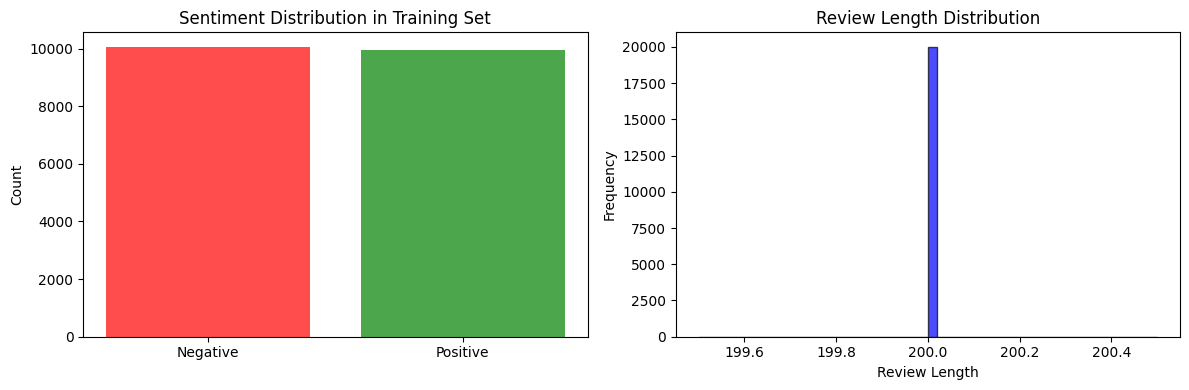

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of labels
sentiment_counts = pd.Series(y_train).value_counts()
axes[0].bar(['Negative', 'Positive'], sentiment_counts.values,
            color=['red', 'green'], alpha=0.7)
axes[0].set_title('Sentiment Distribution in Training Set')
axes[0].set_ylabel('Count')

# Review length distribution
review_lengths = [len(review) for review in X_train]
axes[1].hist(review_lengths, bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[1].set_title('Review Length Distribution')
axes[1].set_xlabel('Review Length')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [ ]:

def create_rnn_model():
    """Create Simple RNN model"""
    model = Sequential([
        Embedding(input_dim=max_features, output_dim=128, input_length=max_len),
        SimpleRNN(64, return_sequences=False),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    return model

def create_lstm_model():
    """Create LSTM model"""
    model = Sequential([
        Embedding(input_dim=max_features, output_dim=128, input_length=max_len),
        LSTM(64, return_sequences=False),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    return model

def create_gru_model():
    """Create GRU model"""
    model = Sequential([
        Embedding(input_dim=max_features, output_dim=128, input_length=max_len),
        GRU(64, return_sequences=False),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    return model

In [ ]:
def train_model(model, model_name, epochs=10, batch_size=128):
    """Train and evaluate a model"""

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Early stopping
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    # Train
    print(f"\n{'='*50}")
    print(f"Training {model_name}...")
    print(f"{'='*50}")

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=1
    )

    return history

In [ ]:
# Create and train all three models
models = {
    'RNN': create_rnn_model(),
    'LSTM': create_lstm_model(),
    'GRU': create_gru_model()
}

histories = {}

for name, model in models.items():
    histories[name] = train_model(model, name)
    print(f"{name} training complete!")


Training RNN...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 149ms/step - accuracy: 0.5117 - loss: 0.6969 - val_accuracy: 0.5238 - val_loss: 0.6906
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 150ms/step - accuracy: 0.5541 - loss: 0.6802 - val_accuracy: 0.5568 - val_loss: 0.6725
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 150ms/step - accuracy: 0.6301 - loss: 0.6045 - val_accuracy: 0.6308 - val_loss: 0.6220
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 150ms/step - accuracy: 0.6963 - loss: 0.5015 - val_accuracy: 0.5340 - val_loss: 0.8575
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 144ms/step - accuracy: 0.7044 - loss: 0.4487 - val_accuracy: 0.5758 - val_loss: 0.8532
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 153ms/step - accuracy: 0.7258 - loss: 0.4021 - val_accuracy: 0.5504 - val_loss: 1.0321
RNN training complete!

Training LSTM...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 70s 428ms/step - accuracy: 0.5257 - loss: 0.6902 - val_accuracy: 0.5474 - val_loss: 0.6770
Epoch 2/10
157/157 ━━━━━━

In [ ]:
def evaluate_model(model, model_name, X_test, y_test):
    """Evaluate model on test data"""

    # Predict
    y_pred_proba = model.predict(X_test)
    y_pred = (y_pred_proba > 0.5).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'])
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{model_name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(report)

    return accuracy, cm, y_pred

# Evaluate all models
results = {}

for name, model in models.items():
    accuracy, cm, _ = evaluate_model(model, name, X_test, y_test)
    results[name] = {'accuracy': accuracy, 'confusion_matrix': cm}


782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step

RNN Results:
Accuracy: 0.6159

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.33      0.46     12500
    Positive       0.57      0.90      0.70     12500

    accuracy                           0.62     25000
   macro avg       0.67      0.62      0.58     25000
weighted avg       0.67      0.62      0.58     25000

782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step

LSTM Results:
Accuracy: 0.8300

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.82      0.83     12500
    Positive       0.82      0.84      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000

782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step

GRU Results:
Accuracy: 0.8520

Classification Report:
              precision    recall  f1-score   suppo

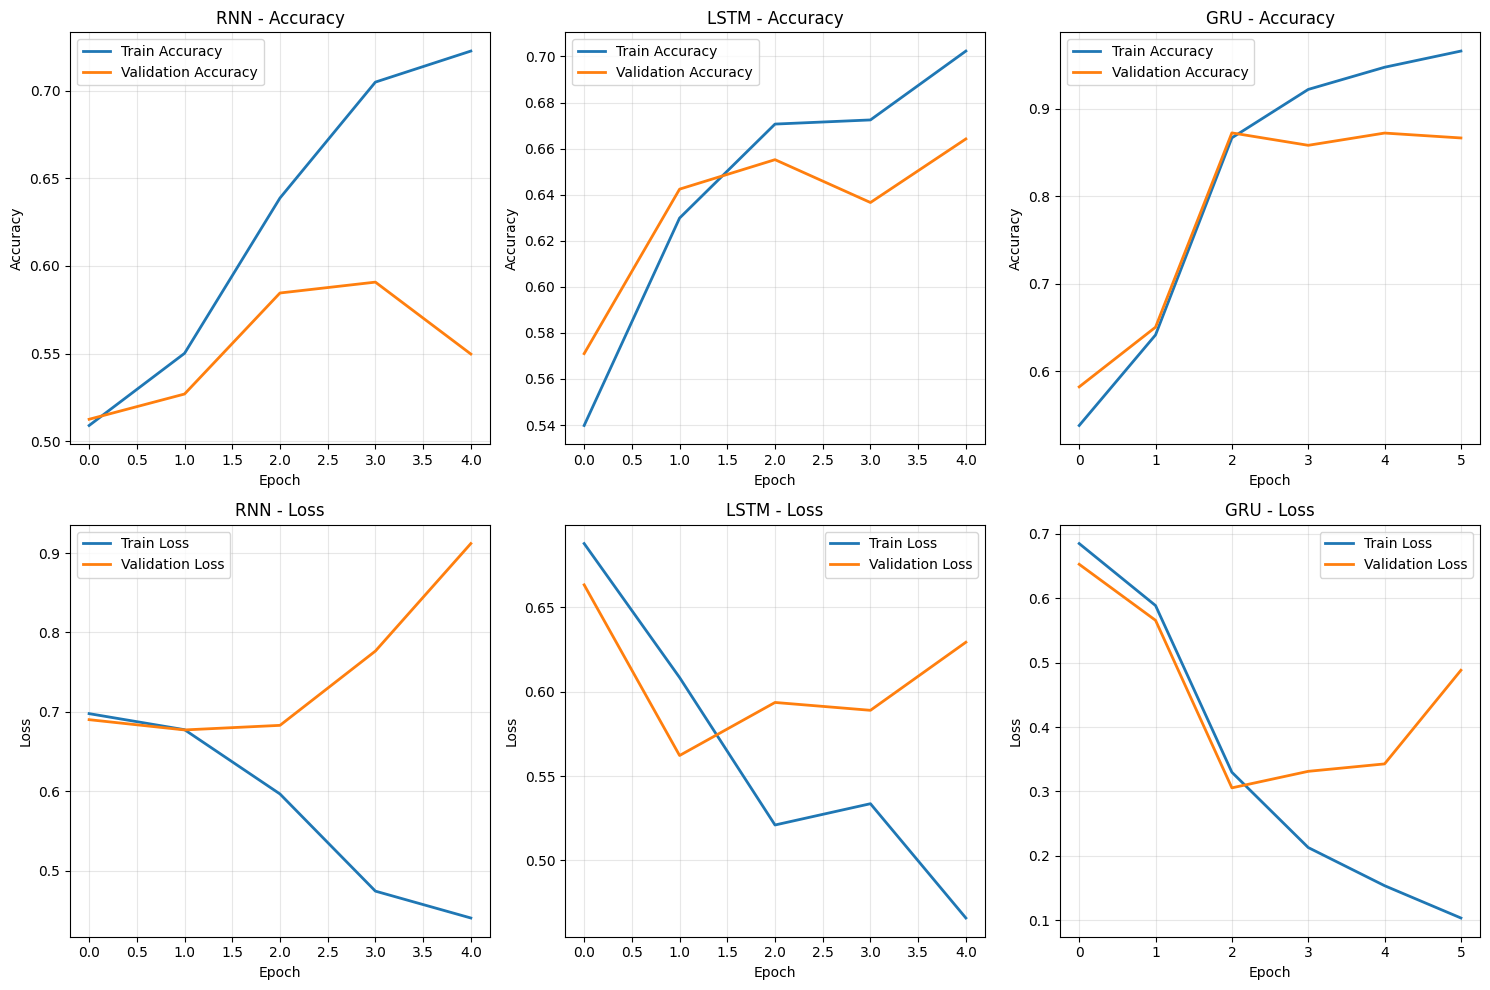

In [ ]:
# Plot training history
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, (name, history) in enumerate(histories.items()):
    # Accuracy plot
    axes[0, idx].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0, idx].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0, idx].set_title(f'{name} - Accuracy')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Accuracy')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)

    # Loss plot
    axes[1, idx].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[1, idx].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1, idx].set_title(f'{name} - Loss')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Loss')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

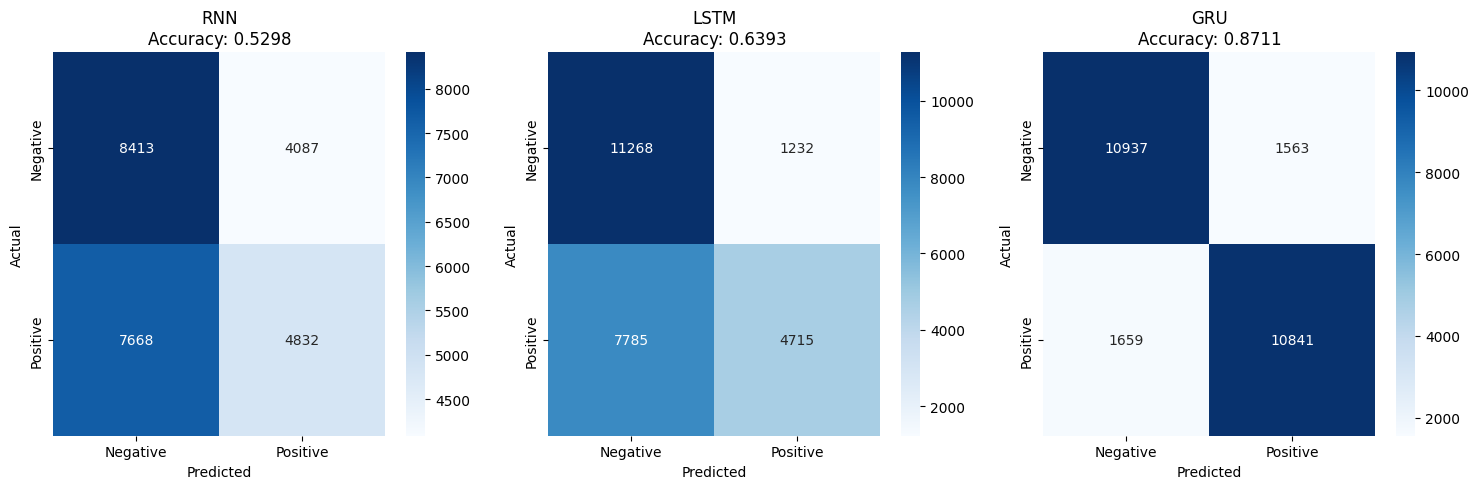

In [ ]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (name, result) in enumerate(results.items()):
    sns.heatmap(result['confusion_matrix'], annot=True, fmt='d',
                cmap='Blues', ax=axes[idx],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[idx].set_title(f'{name}\nAccuracy: {result["accuracy"]:.4f}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

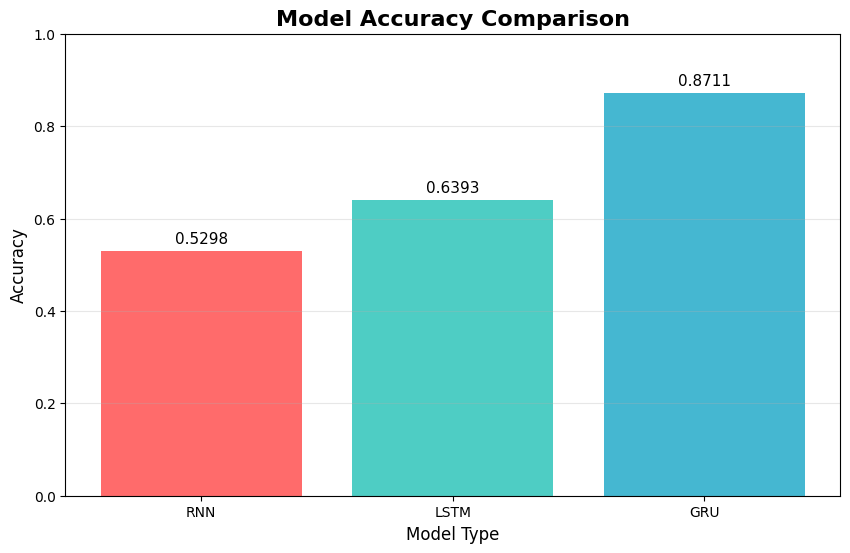

In [ ]:
# Create comparison bar chart
model_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names]

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Model Type', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11)

plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [ ]:
# Word index for converting text to sequences
word_index = imdb.get_word_index()
word_index = {k: (v+3) for k, v in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2
word_index["<UNUSED>"] = 3

def review_to_sequence(review_text):
    """Convert review text to sequence of word indices"""
    words = review_text.lower().split()
    sequence = []
    for word in words:
        if word in word_index:
            sequence.append(word_index[word])
        else:
            sequence.append(2)  # <UNK> token
    return sequence

def predict_sentiment(model, review_text, model_name):
    """Predict sentiment of a custom review"""
    # Convert to sequence and pad
    seq = review_to_sequence(review_text)
    padded_seq = sequence.pad_sequences([seq], maxlen=max_len, padding='post')

    # Predict
    prediction = model.predict(padded_seq, verbose=0)[0][0]
    sentiment = "Positive 😊" if prediction > 0.5 else "Negative 😞"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    print(f"\n{model_name} Sentiment Analysis:")
    print(f"Review: {review_text}")
    print(f"Sentiment: {sentiment} (Confidence: {confidence:.2%})")
    print(f"Raw Score: {prediction:.4f}")
    return prediction

In [ ]:
# Test with custom reviews
test_reviews = [
    "This movie was absolutely fantastic! Great acting and amazing storyline.",
    "Terrible film, worst I've ever seen. Complete waste of time and money.",
    "The movie was okay, nothing special but not bad either.",
    "I loved every minute of this masterpiece! Highly recommended.",
    "Predictable plot and wooden acting made this film unbearable."
]

print("\n" + "="*50)
print("TESTING WITH CUSTOM REVIEWS")
print("="*50)

for review in test_reviews:
    print("\n" + "-"*50)
    for name, model in models.items():
        predict_sentiment(model, review, name)
    print("-"*50)


TESTING WITH CUSTOM REVIEWS

--------------------------------------------------

RNN Sentiment Analysis:
Review: This movie was absolutely fantastic! Great acting and amazing storyline.
Sentiment: Positive 😊 (Confidence: 52.51%)
Raw Score: 0.5251

LSTM Sentiment Analysis:
Review: This movie was absolutely fantastic! Great acting and amazing storyline.
Sentiment: Positive 😊 (Confidence: 83.76%)
Raw Score: 0.8376

GRU Sentiment Analysis:
Review: This movie was absolutely fantastic! Great acting and amazing storyline.
Sentiment: Positive 😊 (Confidence: 75.52%)
Raw Score: 0.7552
--------------------------------------------------

--------------------------------------------------

RNN Sentiment Analysis:
Review: Terrible film, worst I've ever seen. Complete waste of time and money.
Sentiment: Positive 😊 (Confidence: 52.51%)
Raw Score: 0.5251

LSTM Sentiment Analysis:
Review: Terrible film, worst I've ever seen. Complete waste of time and money.
Sentiment: Negative 😞 (Confidence: 76.79%)
R

In [ ]:
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)

summary_df = pd.DataFrame({
    'Model': model_names,
    'Test Accuracy': [results[name]['accuracy'] for name in model_names]
})

summary_df['Best'] = summary_df['Test Accuracy'] == summary_df['Test Accuracy'].max()
print(summary_df.to_string(index=False))

best_model = summary_df[summary_df['Best']]['Model'].values[0]
print(f"\n🏆 Best Performing Model: {best_model}")
print(f"   Accuracy: {summary_df[summary_df['Best']]['Test Accuracy'].values[0]:.4f}")



MODEL COMPARISON SUMMARY
Model  Test Accuracy  Best
  RNN        0.52980 False
 LSTM        0.63932 False
  GRU        0.87112  True

🏆 Best Performing Model: GRU
   Accuracy: 0.8711


In [ ]:
# save models
for name, model in models.items():
    model.save(f'sentiment_{name.lower()}_model.h5')
    print(f"Saved {name} model")

print("\n✅ Sentiment Analysis Complete!")